In [ ]:
# ======================================================
# 🧩 1. IMPORTS & INITIAL SETUP
# ======================================================
import os
import sys
import csv
import importlib
from datetime import datetime
from PIL import ImageFile
from google.colab import drive

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall
import matplotlib.pyplot as plt
import numpy as np

# additional imports for ResNet50
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# FIX TRUNCATED/CORRUPTED IMAGES
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ======================================================
# 🌐 2. LOAD LOCAL PREPROCESSING SCRIPT
# ======================================================
PREPROCESSING_PATH = '/content/preprocessing_leukemia_imagenet_2.py'
sys.path.append(os.path.dirname(PREPROCESSING_PATH))

import preprocessing_leukemia_imagenet_2
importlib.reload(preprocessing_leukemia_imagenet_2)
from preprocessing_leukemia_imagenet_2 import preprocess_leukemia_dataset

# ======================================================
# 💾 3. MOUNT GOOGLE DRIVE
# ======================================================
drive.mount('/content/drive')

# DEFINE PATHS
RAW_DATA_DIR = '/content/drive/MyDrive/Research/DataFolder'
DEST_DIR = '/content/drive/MyDrive/Research/leukemia_cleaned_new'
RESULTS_DIR = '/content/drive/MyDrive/Research/Results_new'
LOG_FILE = os.path.join(RESULTS_DIR, 'training_logs.csv')

os.makedirs(DEST_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ======================================================
# 🧼 4. RUN PREPROCESSING (use 224x224 for ResNet50)
# ======================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen, val_gen, test_gen = preprocess_leukemia_dataset(
    input_path=RAW_DATA_DIR,
    output_path=DEST_DIR,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# ======================================================
# 🏗️ 5. MODEL DEVELOPMENT (ResNet50 transfer learning)
# ======================================================
def build_resnet50_binary_model(input_shape=(224,224,3), lr=1e-4, freeze_base=True):
    base = ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
    if freeze_base:
        for layer in base.layers:
            layer.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(1, activation='sigmoid')(x)  # ✅ Single neuron for binary

    model = Model(inputs=base.input, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',  # ✅ Binary loss
        metrics=['accuracy', Precision(name='Precision'), Recall(name='Recall')]
    )
    return model

model = build_resnet50_binary_model(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), lr=1e-4, freeze_base=True)
model.summary()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset reorganized into: ['ALLNeg', 'ALLPos', 'train', 'val', 'test']
✅ Data split into train / val / test folders.
Found 3244 images belonging to 2 classes.
Found 1815 images belonging to 2 classes.
Found 1791 images belonging to 2 classes.
✅ Generators ready.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# ======================================================
# 🚀 6. TRAINING
# ======================================================
checkpoint_path = os.path.join(RESULTS_DIR, 'best_leukemia_model_resnet50.keras')

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=[checkpoint, early_stop],
    verbose=1
)


 88/101 ━━━━━━━━━━━━━━━━━━━━ 1:10 5s/step - Precision: 0.8324 - Recall: 1.0000 - accuracy: 0.8326 - loss: 0.4092

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 972ms/step - Precision: 0.8445 - Recall: 0.8041 - accuracy: 0.7043 - loss: 0.6255
Epoch 1: val_accuracy improved from -inf to 0.84022, saving model to /content/drive/MyDrive/Research/Results_new/best_leukemia_model_resnet50.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 614s 6s/step - Precision: 0.8445 - Recall: 0.8054 - accuracy: 0.7052 - loss: 0.6245 - val_Precision: 0.8402 - val_Recall: 1.0000 - val_accuracy: 0.8402 - val_loss: 0.4312
Epoch 2/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - Precision: 0.8559 - Recall: 0.9946 - accuracy: 0.8520 - loss: 0.4303
Epoch 2: val_accuracy did not improve from 0.84022
102/102 ━━━━━━━━━━━━━━━━━━━━ 59s 580ms/step - Precision: 0.8558 - Recall: 0.9947 - accuracy: 0.8519 - loss: 0.4304 - val_Precision: 0.8402 - val_Recall: 1.0000 - val_accuracy: 0.8402 - val_loss: 0.4207
Epoch 3/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - Precision: 0.8436 - Recall: 0.9983 - accuracy: 0.8424 - loss: 0.4339
Epoch 3: val_accuracy di

57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - Precision: 0.8705 - Recall: 1.0000 - accuracy: 0.8746 - loss: 0.3011
57/57 ━━━━━━━━━━━━━━━━━━━━ 15s 187ms/step

===== Validation Metrics =====
Accuracy      : 0.8738
Loss          : 0.2962
Precision     : 0.8694
Recall        : 1.0000
F1 Score      : 0.9302
ROC-AUC       : 0.5172
✅ Metrics logged to /content/drive/MyDrive/Research/Results_new/training_logs.csv


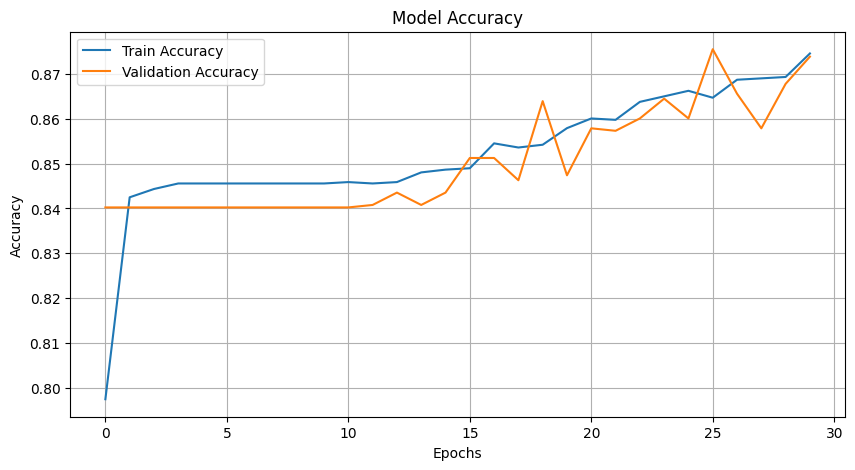

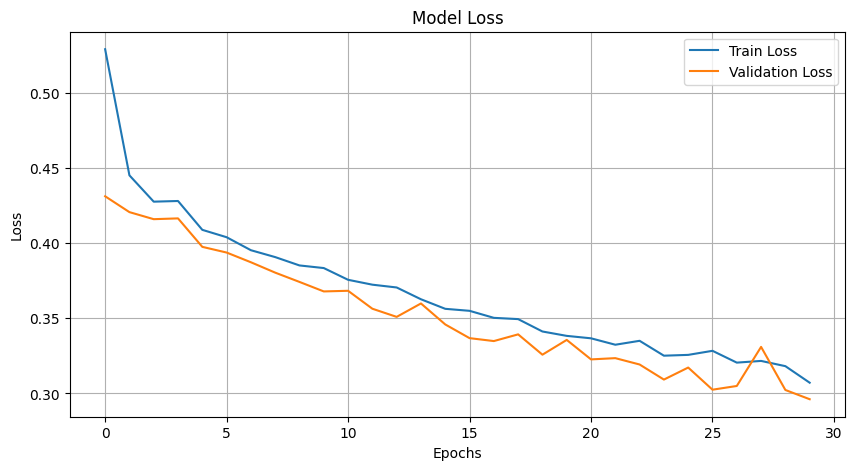

✅ Final model saved at: /content/drive/MyDrive/Research/Results_new/leukemia_final_model_resnet50.keras


In [ ]:
# ======================================================
# 🧪 7. EVALUATION (BINARY CLASSIFICATION)
# ======================================================
from sklearn.metrics import roc_auc_score
import numpy as np

# Evaluate
test_loss, test_acc, test_precision, test_recall = model.evaluate(val_gen, verbose=1)

# F1 score
test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall + 1e-7)

# ROC-AUC for BINARY
y_true = val_gen.classes  # 0 or 1
y_pred_probs = model.predict(val_gen).ravel()  # Flatten predictions

roc_auc = roc_auc_score(y_true, y_pred_probs)

print("\n===== Validation Metrics =====")
print(f"Accuracy      : {test_acc:.4f}")
print(f"Loss          : {test_loss:.4f}")
print(f"Precision     : {test_precision:.4f}")
print(f"Recall        : {test_recall:.4f}")
print(f"F1 Score      : {test_f1:.4f}")
print(f"ROC-AUC       : {roc_auc:.4f}")

# ======================================================
# 📊 8. LOG TRAINING RESULTS TO CSV
# ======================================================
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

def safe_get(metric):
    return history.history.get(metric, [None])[-1]

row = [
    timestamp,
    safe_get('accuracy'),
    safe_get('val_accuracy'),
    safe_get('loss'),
    safe_get('val_loss'),
    safe_get('precision'),
    safe_get('val_precision'),
    safe_get('recall'),
    safe_get('val_recall'),
    max(history.history.get('val_accuracy', [0])),
    min(history.history.get('val_loss', [999])),
    test_acc, test_loss, test_precision, test_recall, test_f1, roc_auc,
    len(history.history.get('accuracy', [])),
    (safe_get('accuracy') or 0) - (safe_get('val_accuracy') or 0),
    model.count_params()
]

header = [
    'Timestamp','Train_Acc','Val_Acc','Train_Loss','Val_Loss',
    'Train_Precision','Val_Precision','Train_Recall','Val_Recall',
    'Best_Val_Acc','Best_Val_Loss',
    'Test_Acc','Test_Loss','Test_Precision','Test_Recall','Test_F1','Test_ROC_AUC',
    'Epochs_Trained','Overfitting_Gap','Total_Params'
]

# Create or append CSV
if not os.path.exists(LOG_FILE):
    with open(LOG_FILE, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(header)
        writer.writerow(row)
else:
    with open(LOG_FILE, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(row)

print(f"✅ Metrics logged to {LOG_FILE}")

# ======================================================
# 📈 9. VISUALIZE TRAINING CURVES
# ======================================================
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# ======================================================
# 💾 10. SAVE FINAL MODEL (.keras FORMAT)
# ======================================================
FINAL_MODEL_PATH = os.path.join(RESULTS_DIR, 'leukemia_final_model_resnet50.keras')
model.save(FINAL_MODEL_PATH)
print(f"✅ Final model saved at: {FINAL_MODEL_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model loaded successfully from: /content/drive/MyDrive/Research/Results_new/best_leukemia_model_resnet50.keras


Saving WBC-Benign-012.jpg to WBC-Benign-012 (1).jpg
User uploaded file WBC-Benign-012 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


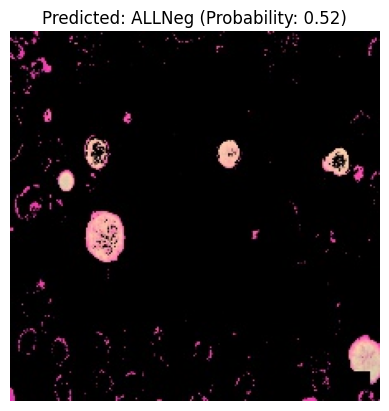

Prediction for WBC-Benign-012 (1).jpg: ALLNeg with probability 0.5244


In [4]:
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import files
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model # Import load_model
import os
from google.colab import drive

drive.mount('/content/drive')

# ======================================================
# 🖼️ 11. PREDICT ON SINGLE UPLOADED IMAGE
# ======================================================

# Helper function to preprocess the image
def preprocess_single_image(img_path, target_size):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch
    img_array /= 255.0  # Normalize to [0,1] as done during training
    return img_array

# Re-define IMG_SIZE and model path for this cell to ensure they're available
IMG_SIZE = (224, 224)
RESULTS_DIR = '/content/drive/MyDrive/Research/Results_new'
FINAL_MODEL_PATH = os.path.join(RESULTS_DIR, 'best_leukemia_model_resnet50.keras')

# Load the trained model
try:
    model = load_model(FINAL_MODEL_PATH)
    print(f"✅ Model loaded successfully from: {FINAL_MODEL_PATH}")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    print("Please ensure the model has been trained and saved, and that Google Drive is mounted.")
    # Exit or handle the error gracefully if the model cannot be loaded
    exit()


# Upload image
uploaded = files.upload()

for fn in uploaded.keys():
    print(f"User uploaded file " + fn)
    # Preprocess the uploaded image
    img_array = preprocess_single_image(fn, IMG_SIZE)

    # Make prediction
    prediction = model.predict(img_array)

    # Interpret prediction for binary classification
    # Assuming 0 is ALLNeg and 1 is ALLPos based on generator class indices if available,
    # or explicit definition. Here, we'll assume 0.5 as threshold.
    if prediction[0][0] >= 0.5:
        predicted_class = 'ALLPos'
        probability = prediction[0][0]
    else:
        predicted_class = 'ALLNeg'
        probability = 1 - prediction[0][0] # Probability of being ALLNeg

    # Display the image and prediction
    plt.imshow(image.load_img(fn, target_size=IMG_SIZE))
    plt.title(f"Predicted: {predicted_class} (Probability: {probability:.2f})")
    plt.axis('off')
    plt.show()

    print(f"Prediction for {fn}: {predicted_class} with probability {probability:.4f}")